In [1]:
import nifty.re as jft
import jax.random as random
import jax
import jax.numpy as jnp
import numpy as np
# from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import seaborn as sns

In [2]:
# enable float64 precision
jax.config.update("jax_enable_x64", True)

# initialize JAX random key
seed = 42
key = random.PRNGKey(seed)

In [3]:
def inv_cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.inv(jax.scipy.linalg.toeplitz(cov0))

In [4]:
def inv_std(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    Cov = jax.scipy.linalg.toeplitz(cov0)
    L = jax.scipy.linalg.cholesky(Cov)
    return jax.scipy.linalg.inv(L)

In [5]:
def cov(Ns, A, omega0, gamma, p, C):
    omega = np.fft.rfftfreq(1024, d=5e-9)/1e+8
    fourier = np.abs(A*(1/(1+(np.abs(omega-omega0)/gamma)**(2*p))+C))
    cov0 = np.fft.irfft(fourier)[:Ns]
    return jax.scipy.linalg.toeplitz(cov0)

In [11]:
def compare_plot(samples, x, y_true, compare="true"):

    y_samples = tuple(my_model(s) for s in samples)
    y_mean = jft.mean(y_samples)

    # calculate statistical measurements
    diff = y_mean - y_true
    rmse = np.sqrt(np.mean(diff**2)) #Root mean square

    # plot
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # vertical lines
    for j in range(2):
         for i in range(len(x)):
            axes[j].axvline(i*5, c="lightgray", linestyle="--")

    # first plot
    axes[0].plot(x, y_true, label=compare)
    axes[0].plot(x, y_mean, label=f"nifty mean")
    
    axes[0].set_ylabel(r"Signal")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray")
    axes[1].plot(x, diff, label=f"RMSE = {rmse:.2f}")

    axes[1].set_ylabel(r"Residual")
    axes[1].legend()
    plt.xlabel(r"$t$ [ns]")

    plt.show()

In [7]:
# measurement locations and data
t200 = np.load("data/time_200.npy")
d200 = np.load("data/true_trace_200.npy")
d200_noise = np.load("data/trace_200_simnoise.npy")

In [8]:
# likelihood
A=2.89331354e-07
omega0=5.85403204e-01
gamma=2.70651972e-02
p=9.21301273e-01
C=-7.39389317e-03

# models for a and b
a = jft.LogNormalPrior(mean=4, std=3, name="a_input")
# b = jft.NormalPrior(mean=0, std=3, name="b_input")

# linear regression model
class LinearModel(jft.Model):
    def __init__(self, x, a):
        self.x = x
        super().__init__(domain=a.domain, white_init=True)

    def __call__(self, inp):
        return self.x

my_model = LinearModel(d200_noise, a)

Inv_Cov = inv_cov(len(d200_noise), A, omega0, gamma, p, C)
Inv_Std = inv_std(len(d200_noise), A, omega0, gamma, p, C)

noise_cov_inv = lambda x: jnp.matmul(Inv_Cov, x)
noise_std_inv = lambda x: jnp.matmul(Inv_Std, x)


lh = jft.Gaussian(data=d200_noise, noise_cov_inv=noise_cov_inv, noise_std_inv=noise_std_inv).amend(my_model)

key, subkey = random.split(key, 2)
init_pos = lh.init(subkey)
print("initial position: ", init_pos)
init_pos = jft.Vector(init_pos)
print("initial position vector: ", init_pos)

n_vi_iterations = 6
n_samples = 4
key, sampling_key = random.split(key, 2)

draw_linear_kwargs = dict(
    cg_name=None,
    cg_kwargs=dict(absdelta=1e-5 * jft.size(lh.domain), maxiter=100),
)

kl_kwargs = dict(minimize_kwargs=dict(name=None, xtol=1e-4, maxiter=35))

sample_mode = "linear_resample"

optimize_kl_args = dict(
    likelihood=lh,
    position_or_samples=init_pos,
    n_total_iterations=n_vi_iterations,
    n_samples=n_samples,
    key=sampling_key,
    draw_linear_kwargs=draw_linear_kwargs,
    kl_kwargs=kl_kwargs,
    sample_mode=sample_mode,
)

s, state = jft.optimize_kl(**optimize_kl_args)

OPTIMIZE_KL: Starting 0001


initial position:  {'a_input': Array(-0.44370261, dtype=float64)}
initial position vector:  Vector({'a_input': Array(-0.44370261, dtype=float64)})


CG: gamma=0, converged!
OPTIMIZE_KL: Iteration 0001 E:+1.4511e-01
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 2
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     0.0±     0.0, avg:     +0.0±     0.0, #dof:    200'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:    0.29±    0.37, avg:     +0.0±    0.54, #dof:      1'


OPTIMIZE_KL: Starting 0002
OPTIMIZE_KL: Iteration 0002 E:+5.8357e-01
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     0.0±     0.0, avg:     +0.0±     0.0, #dof:    200'

OPTIMIZE_KL: Prior residual(s):
a_input                 :: 'reduced Chi²:     1.2±     1.7, avg:     +0.0±     1.1, #dof:      1'


OPTIMIZE_KL: Starting 0003
OPTIMIZE_KL: Iteration 0003 E:+1.5797e-01
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced C

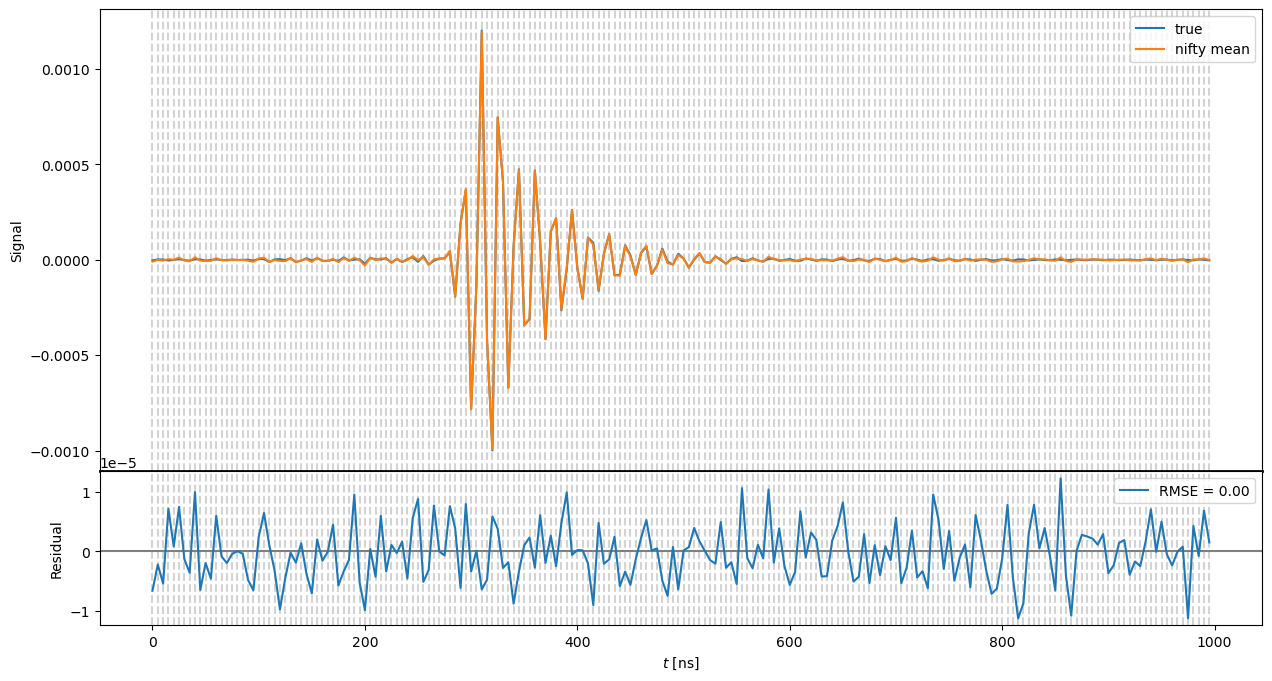

In [12]:
compare_plot(s, t200, d200)

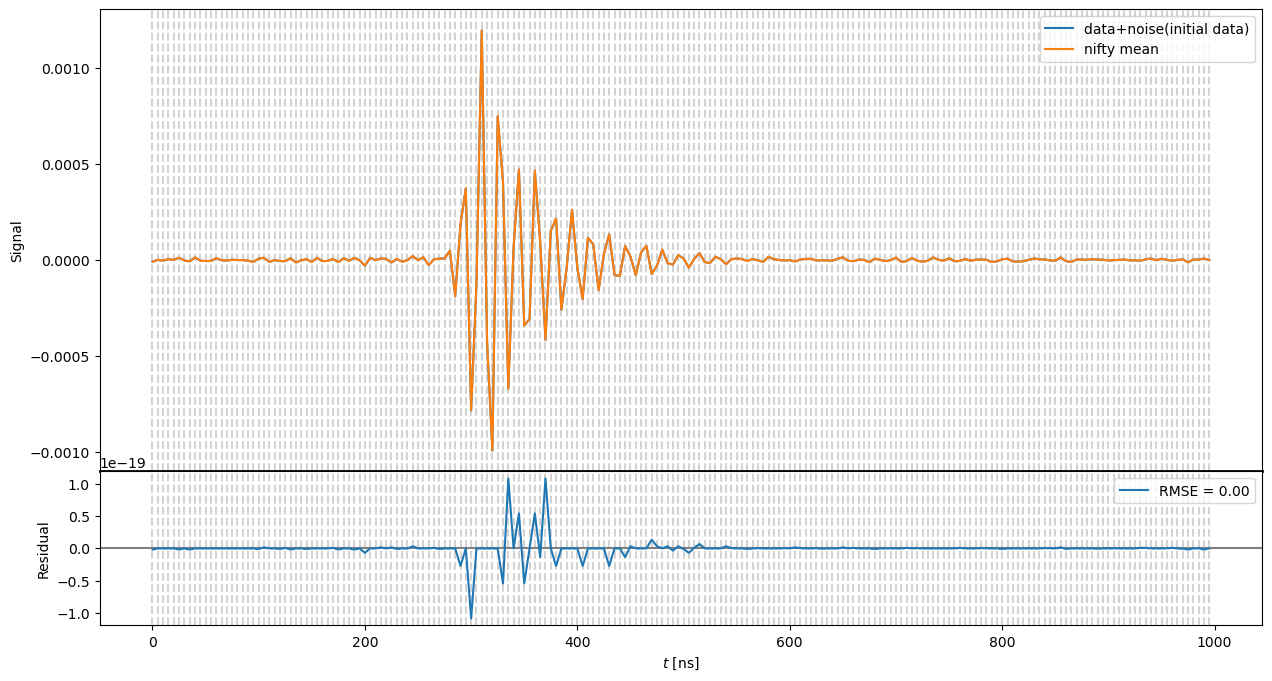

In [13]:
compare_plot(s, t200, d200_noise, "data+noise(initial data)")